In [27]:
import scanpy as sc
import anndata
import math
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, roc_curve, roc_auc_score, f1_score, classification_report
from sklearn.model_selection import GroupKFold
from collections import Counter
import scipy.sparse as sp
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

In [2]:
adata_ref = sc.read_h5ad("data/sce_relabel.h5ad")
adata_query = sc.read_h5ad("data/sce_query.h5ad")
adata_ref = adata_ref[adata_ref.obs["ethnicity_relabel"]!= "LowConfidenceLabel", :]

In [3]:
adata_ref

View of AnnData object with n_obs × n_vars = 2997 × 12789
    obs: 'sample_id', 'is_immune', 'do_analyse', 'donor_id', 'title', 'dataset_id', 'collection_id', 'age_days', 'sex', 'ethnicity_groups', 'tissue_groups', 'assay_groups', 'disease_groups', 'age_years', 'age_bin', 'age_decade', 'TMM', 'multiplier', 'assay_groups___altered', 'dataset_id___altered', 'disease_groups___altered', 'offset', 'clusters', 'entropy', 'entropy_study', 'alpha', 'runner_up', 'margin', 'local_entropy', 'local_entropy_norm', 'score', 'ethnicity_relabel'
    var: 'is_gene_shared', '.abundant', 'Estimate_Europeans', 'Estimate_EastAsian', 'Estimate_SouthAsian', 'Estimate_African', 'Estimate_HispanicDLatinAmerican', 'Est.Error_Europeans', 'Est.Error_EastAsian', 'Est.Error_SouthAsian', 'Est.Error_African', 'Est.Error_HispanicDLatinAmerican', 'CI.Lower_Europeans', 'CI.Lower_EastAsian', 'CI.Lower_SouthAsian', 'CI.Lower_African', 'CI.Lower_HispanicDLatinAmerican', 'CI.Upper_Europeans', 'CI.Upper_EastAsian', 'CI.Upper

In [4]:
adata_query

AnnData object with n_obs × n_vars = 2011 × 12789
    obs: 'sample_id', 'is_immune', 'do_analyse', 'donor_id', 'title', 'dataset_id', 'collection_id', 'age_days', 'sex', 'ethnicity_groups', 'tissue_groups', 'assay_groups', 'disease_groups', 'age_years', 'age_bin', 'age_decade', 'TMM', 'multiplier', 'assay_groups___altered', 'dataset_id___altered', 'disease_groups___altered', 'offset'
    var: 'is_gene_shared', '.abundant', 'Estimate_Europeans', 'Estimate_EastAsian', 'Estimate_SouthAsian', 'Estimate_African', 'Estimate_HispanicDLatinAmerican', 'Est.Error_Europeans', 'Est.Error_EastAsian', 'Est.Error_SouthAsian', 'Est.Error_African', 'Est.Error_HispanicDLatinAmerican', 'CI.Lower_Europeans', 'CI.Lower_EastAsian', 'CI.Lower_SouthAsian', 'CI.Lower_African', 'CI.Lower_HispanicDLatinAmerican', 'CI.Upper_Europeans', 'CI.Upper_EastAsian', 'CI.Upper_SouthAsian', 'CI.Upper_African', 'CI.Upper_HispanicDLatinAmerican', 'Star_Europeans', 'Star_EastAsian', 'Star_SouthAsian', 'Star_African', 'Star_His

In [8]:
labels = adata_ref.obs["ethnicity_relabel"].values
ethnicity_to_idx = {
    'African': 0,
    'EastAsian': 1,
    'European': 2,
    'Hispanic': 3,
    'SouthAsian': 4
}
labels_int = np.array([ethnicity_to_idx[label] for label in labels])

In [6]:
def to_dense(x):
    if sp.issparse(x):
        return x.toarray()
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)

def extract_layer(adata, layer_name, mask=None):
    X = adata.layers[layer_name] if mask is None else adata[:, mask].layers[layer_name]
    return to_dense(X).astype(np.float32, copy=False)


def build_group_holdout_splits(group_values, y, class_ids, n_splits=5, random_state=52, group_name="group", protected_groups=None):
    rng = np.random.default_rng(random_state)
    df = pd.DataFrame({"idx": np.arange(len(y)), "group_value": group_values, "y": y})
    protected_groups = [] if protected_groups is None else [str(g).lower() for g in protected_groups]

    group_class = (
        df.groupby(["group_value", "y"]).size().unstack(fill_value=0).reindex(columns=class_ids, fill_value=0)
    )
    group_sizes = df.groupby("group_value").size().reindex(group_class.index)
    class_group_counts = (group_class > 0).sum(axis=0)

    insufficient = class_group_counts[class_group_counts < 2]

    coverage = {grp: [c for c in class_ids if group_class.loc[grp, c] > 0] for grp in group_class.index}
    group_names = group_class.index.to_list()
    candidate_group_names = [grp for grp in group_names if str(grp).lower() not in protected_groups]
    total_samples = int(group_sizes.sum())
    target_test_n = math.ceil(total_samples / n_splits)
    usage_counts = {grp: 0 for grp in group_names}

    split_defs = []
    heldout_groups = []

    for split_idx in range(n_splits):
        selected = []
        covered = set()
        current_n = 0

        while True:
            remaining = [c for c in class_ids if c not in covered]
            candidates = [grp for grp in candidate_group_names if grp not in selected]

            if not remaining and current_n >= target_test_n:
                break
            if not candidates:
                break

            candidate_rows = []
            for grp in candidates:
                train_groups = [g for g in group_names if g not in (selected + [grp])]
                train_cover = set()
                for train_grp in train_groups:
                    train_cover.update(coverage[train_grp])
                if not set(class_ids).issubset(train_cover):
                    continue

                gained = [c for c in remaining if c in coverage[grp]]
                candidate_rows.append(
                    {
                        "group_value": grp,
                        "gain": len(gained),
                        "rarity_gain": float(sum(1.0 / class_group_counts[c] for c in gained)) if gained else 0.0,
                        "usage": usage_counts[grp],
                        "n_samples": int(group_sizes.loc[grp]),
                        "size_gap": abs((current_n + int(group_sizes.loc[grp])) - target_test_n),
                        "tie_break": float(rng.random()),
                    }
                )

            if not candidate_rows:
                break

            candidate_df = pd.DataFrame(candidate_rows)
            if remaining:
                candidate_df = candidate_df.sort_values(
                    ["gain", "rarity_gain", "usage", "size_gap", "tie_break"],
                    ascending=[False, False, True, True, True],
                    kind="mergesort",
                )
            else:
                candidate_df = candidate_df.sort_values(
                    ["usage", "size_gap", "rarity_gain", "tie_break"],
                    ascending=[True, True, False, True],
                    kind="mergesort",
                )

            chosen = candidate_df.iloc[0]["group_value"]
            selected.append(chosen)
            covered.update(coverage[chosen])
            current_n += int(group_sizes.loc[chosen])
            usage_counts[chosen] += 1

        train_groups = [g for g in group_names if g not in selected]
        train_cover = set()
        for train_grp in train_groups:
            train_cover.update(coverage[train_grp])

        te_idx = df.loc[df["group_value"].isin(selected), "idx"].to_numpy(dtype=int)
        tr_idx = np.setdiff1d(np.arange(len(y)), te_idx)
        split_defs.append((tr_idx, te_idx))
        heldout_groups.append(selected)

    return split_defs, heldout_groups


def make_split_plan(split_scheme, group_values):
    protected_groups = ["blood"] if split_scheme == "tissue_groups" else []
    split_defs, heldout_groups = build_group_holdout_splits(
        group_values=group_values,
        y=y,
        class_ids=class_ids,
        n_splits=n_splits,
        random_state=split_seed,
        group_name=split_scheme,
        protected_groups=protected_groups,
    )
    return {
        "split_scheme": split_scheme,
        "group_values": group_values,
        "split_defs": split_defs,
        "heldout_groups": heldout_groups,
    }


,split_scheme,fold,heldout_groups,n_test_samples,African,EastAsian,European,Hispanic,SouthAsian
0,dataset_id,1,"2a498ace-872a-4935-984b-1afa70fd9886, 842c6f5d...",600,120,4,458,14,4
1,dataset_id,2,"edc8d3fe-153c-4e3d-8be0-2108d30f8d70, 7f08cbcc...",995,11,3,974,1,6
2,dataset_id,3,"2a498ace-872a-4935-984b-1afa70fd9886, 19e46756...",1443,33,868,404,20,118
3,dataset_id,4,"edc8d3fe-153c-4e3d-8be0-2108d30f8d70, 842c6f5d...",613,134,3,457,13,6
4,dataset_id,5,"2a498ace-872a-4935-984b-1afa70fd9886, 01ad3cd7...",1020,3,4,1008,1,4
5,tissue_groups,1,"nasal, oral, and pharyngeal regions, respirato...",600,143,11,415,25,6
6,tissue_groups,2,"nasal, oral, and pharyngeal regions, cardiovas...",700,78,33,564,19,6
7,tissue_groups,3,"nasal, oral, and pharyngeal regions, breast, c...",651,138,31,454,22,6
8,tissue_groups,4,"nasal, oral, and pharyngeal regions, respirato...",601,115,13,441,26,6
9,tissue_groups,5,"nasal, oral, and pharyngeal regions, epitheliu...",623,114,21,450,32,6


,holdout_group,n_samples,split_scheme,fold,split,prop_samples
26,842c6f5d-4a94-4eef-8510-8c792d1124bc,153,dataset_id,1,Test,0.255000
27,093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f,106,dataset_id,1,Test,0.176667
28,9f222629-9e39-47d0-b83f-e08d610c7479,89,dataset_id,1,Test,0.148333
29,d4e69e01-3ba2-4d6b-a15d-e7048f78f22e,87,dataset_id,1,Test,0.145000
30,dea717d4-7bc0-4e46-950f-fd7e1cc8df7d,71,dataset_id,1,Test,0.118333
...,...,...,...,...,...,...
267,blood,2127,tissue_groups,5,Train,0.895956
268,renal system,168,tissue_groups,5,Train,0.070767
269,adipose tissue,43,tissue_groups,5,Train,0.018113
270,female reproductive system,30,tissue_groups,5,Train,0.012637


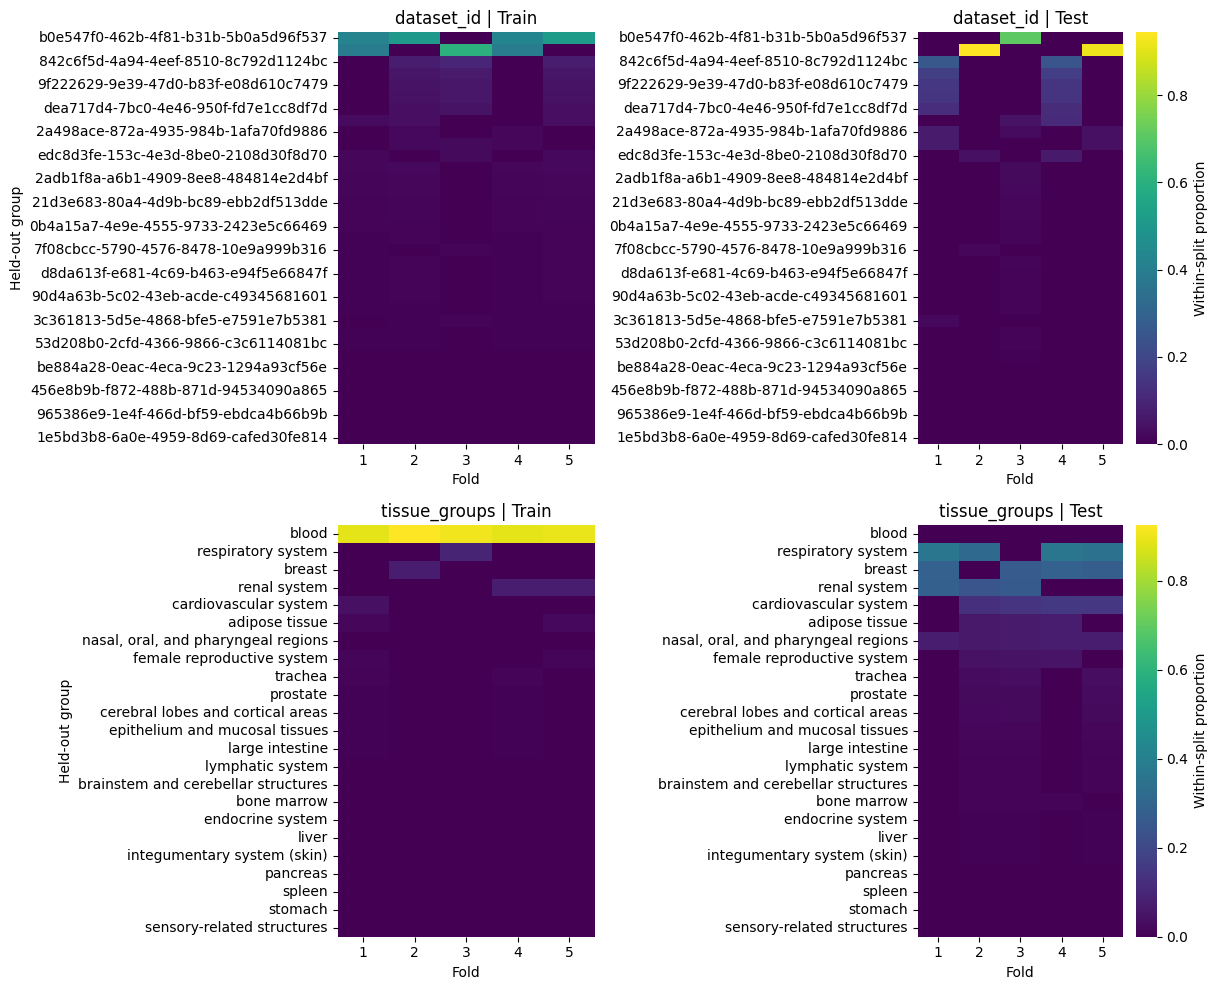

In [9]:
idx_to_eth = {v: k for k, v in ethnicity_to_idx.items()}
class_ids = sorted(idx_to_eth.keys())
class_names = [idx_to_eth[i] for i in class_ids]
N_PCS = 30
split_seed = 52
n_splits = 5

feature_blocks = [
    {"label": "LogCPM", "layer": "logcounts"},
    {"label": "Log1pTMM", "layer": "logcounts_tmm"},
    {"label": "LogCPM_TMM", "layer": "cpm_tmm_logcounts"},
]
reduction_blocks = [("Scale", "scale_only"), ("PCA", "pca")]


marker_mask = adata_ref.var["is_ethnicity_marker"].astype(bool).to_numpy()

y = np.asarray(labels_int, dtype=np.int64)
group_value_map = {
    "dataset_id": adata_ref.obs["dataset_id"].astype(str).to_numpy(),
    "tissue_groups": adata_ref.obs["tissue_groups"].astype(str).to_numpy(),
}


feature_matrices = {}
for feature_block in feature_blocks:
    feature_matrices[(feature_block["label"], "S")] = extract_layer(
        adata_ref,
        feature_block["layer"],
        marker_mask,
    )

feature_recipes = []
for feature_block in feature_blocks:
    X = feature_matrices[(feature_block["label"], "S")]
    for reduction_label, feature_mode in reduction_blocks:
        feature_recipes.append(
            {
                "name": f"{feature_block['label']}_S_{reduction_label}",
                "X": X,
                "feature_mode": feature_mode,
            }
        )

rank_recipe = {
    "name": "LogCPM_S_Rank",
    "X": feature_matrices[("LogCPM", "S")],
    "feature_mode": "rank",
}

split_plan_dict = {
    split_scheme: make_split_plan(split_scheme, group_values)
    for split_scheme, group_values in group_value_map.items()
}

split_summary_rows = []
cv_group_dist_parts = []
for split_scheme, plan in split_plan_dict.items():
    for fold, (_, te_idx) in enumerate(plan["split_defs"], 1):
        test_counts = pd.Series(y[te_idx]).value_counts().reindex(class_ids, fill_value=0)
        split_summary_rows.append(
            {
                "split_scheme": split_scheme,
                "fold": fold,
                "heldout_groups": ", ".join(plan["heldout_groups"][fold - 1]),
                "n_test_samples": int(len(te_idx)),
                **{idx_to_eth[c]: int(test_counts.loc[c]) for c in class_ids},
            }
        )
    for fold, (tr_idx, te_idx) in enumerate(plan["split_defs"], 1):
        for split_name, idx in (("Train", tr_idx), ("Test", te_idx)):
            split_counts = (
                pd.Series(plan["group_values"][idx], name="holdout_group")
                .value_counts()
                .rename_axis("holdout_group")
                .reset_index(name="n_samples")
            )
            split_counts["split_scheme"] = split_scheme
            split_counts["fold"] = fold
            split_counts["split"] = split_name
            split_counts["prop_samples"] = split_counts["n_samples"] / split_counts["n_samples"].sum()
            cv_group_dist_parts.append(split_counts)

split_summary_df = pd.DataFrame(split_summary_rows)
display(split_summary_df)

cv_group_dist_df = pd.concat(cv_group_dist_parts, ignore_index=True)
display(cv_group_dist_df.sort_values(["split_scheme", "split", "fold", "n_samples"], ascending=[True, True, True, False]))

fig, axes = plt.subplots(len(split_plan_dict), 2, figsize=(12, 5 * len(split_plan_dict)), squeeze=False)
for row_idx, (split_scheme, plan) in enumerate(split_plan_dict.items()):
    scheme_df = cv_group_dist_df[cv_group_dist_df["split_scheme"] == split_scheme].copy()
    group_order = (
        scheme_df.groupby("holdout_group")["n_samples"]
        .sum()
        .sort_values(ascending=False)
        .index
        .tolist()
    )
    vmax = scheme_df["prop_samples"].max()
    for col_idx, split_name in enumerate(["Train", "Test"]):
        ax = axes[row_idx, col_idx]
        plot_df = (
            scheme_df[scheme_df["split"] == split_name]
            .pivot(index="holdout_group", columns="fold", values="prop_samples")
            .reindex(group_order)
            .fillna(0)
        )
        sns.heatmap(
            plot_df,
            ax=ax,
            cmap="viridis",
            vmin=0,
            vmax=vmax,
            cbar=(col_idx == 1),
            cbar_kws={"label": "Within-split proportion"} if col_idx == 1 else None,
        )
        ax.set_title(f"{split_scheme} | {split_name}")
        ax.set_xlabel("Fold")
        ax.set_ylabel("Held-out group" if col_idx == 0 else "")

plt.tight_layout()
plt.show()

In [17]:
def fit_scaler_pca(X_tr, n_pcs=N_PCS):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    max_pc = max(2, min(X_tr_s.shape[0], X_tr_s.shape[1]) - 1)
    n_use = min(n_pcs, max_pc)
    pca = PCA(n_components=n_use, random_state=0)
    X_tr_z = pca.fit_transform(X_tr_s)
    return X_tr_z, {"scaler": scaler, "pca": pca}


def fit_scaler_only(X_tr):
    scaler = StandardScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    return X_tr_s, {"scaler": scaler}


def rank_features(X):
    from scipy.stats import rankdata
    return rankdata(X, axis=1, method="average").astype(np.float32)


def fit_feature_space(X_tr, feature_mode="pca", n_pcs=N_PCS):
    if feature_mode == "pca":
        return fit_scaler_pca(X_tr, n_pcs=n_pcs)
    if feature_mode == "scale_only":
        return fit_scaler_only(X_tr)
    if feature_mode == "rank":
        return rank_features(X_tr), None
    raise ValueError(f"Unknown feature_mode: {feature_mode}")


def transform_feature_space(X, transform_obj=None, feature_mode="pca"):
    if feature_mode == "pca":
        return transform_obj["pca"].transform(transform_obj["scaler"].transform(X))
    if feature_mode == "scale_only":
        return transform_obj["scaler"].transform(X)
    if feature_mode == "rank":
        return rank_features(X)
    raise ValueError(f"Unknown feature_mode: {feature_mode}")


def make_model_name(base_name, recipe_name):
    return f"{base_name}__{recipe_name}"


def make_train_components(X_tr, y_tr, batch_size, device, feature_mode="pca", n_pcs=N_PCS):
    X_tr_z, transform_obj = fit_feature_space(X_tr, feature_mode=feature_mode, n_pcs=n_pcs)
    counts = np.bincount(y_tr, minlength=len(class_ids)).astype(np.float32)
    class_weights = counts.sum() / (counts + 1e-6)
    class_weights = class_weights / class_weights.mean()
    class_weights_t = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights_t)
    sample_weights = class_weights[y_tr]
    sampler = WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.float32),
        num_samples=len(sample_weights),
        replacement=True,
    )
    train_dataset = RNADataset(X_tr_z, y_tr)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler)
    return X_tr_z, transform_obj, train_loader, criterion


def build_test_loader(X_te, y_te, transform_obj, batch_size, feature_mode="pca"):
    X_te_z = transform_feature_space(X_te, transform_obj=transform_obj, feature_mode=feature_mode)
    test_dataset = RNADataset(X_te_z, y_te)
    return DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


def predict_labels_pytorch(model, dataloader, device=torch.device("cpu")):
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for xb, yb in dataloader:
            xb = xb.to(device).float()
            logits = model(xb)
            pred = torch.argmax(logits, dim=1)
            ys.append(yb.cpu().numpy())
            ps.append(pred.cpu().numpy())
    return np.concatenate(ys), np.concatenate(ps)
class RNADataset(Dataset):
    def __init__(self, features, labels=None, transform=None):
        self.features = features.astype(np.float32)
        self.labels = labels.astype(np.int64) if labels is not None else None
        self.transform = transform

    def __len__(self):
        return self.features.shape[0]

    def __getitem__(self, idx):
        x = self.features[idx]
        if self.transform:
            x = self.transform(x)
        if self.labels is not None:
            y = self.labels[idx]
            return x, y
        return x

class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dims, num_classes, dropout_prob=0.3):
        super(MLPClassifier, self).__init__()
        layers = []
        prev_dim = input_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev_dim, h))
            layers.append(nn.BatchNorm1d(h))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_prob))
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [23]:
def evaluate_model(model, dataloader, device='cpu'):
    model.eval()
    ys, ps = [], []
    running_loss = 0.0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)

            ys.append(labels.detach().cpu().numpy())
            ps.append(preds.detach().cpu().numpy())

            total += labels.size(0)

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weighted = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    return acc, f1_macro, f1_weighted

def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    val_loader=None,        
    num_epochs=50,
    device='cpu',
    l1_factor=1e-7,
    l2_factor=1e-6,
    print_every=1
):
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.5)

    model.to(device)
    epoch_losses = []
    epoch_accuracies = []
    epoch_lrs = []
    epoch_val_acc = []
    epoch_val_f1m = []
    epoch_val_f1w = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = criterion(outputs, labels)
            penalty = compute_elastic_net_penalty(model, l1_factor, l2_factor)
            loss = loss + penalty

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            preds = torch.argmax(outputs, dim=1)
            correct += torch.sum(preds == labels).item()
            total += labels.size(0)

        epoch_loss = running_loss / total
        epoch_acc = correct / total

        epoch_losses.append(epoch_loss)
        epoch_accuracies.append(epoch_acc)

        current_lr = optimizer.param_groups[0]['lr']
        epoch_lrs.append(current_lr)
        scheduler.step()

        if val_loader is not None:
            val_acc, val_f1m, val_f1w = evaluate_model(model, val_loader, device=device)
            epoch_val_acc.append(val_acc)
            epoch_val_f1m.append(val_f1m)
            epoch_val_f1w.append(val_f1w)

            if (epoch + 1) % print_every == 0:
                print(
                    f"Epoch {epoch+1}/{num_epochs} | "
                    f"TrainLoss={epoch_loss:.4f} TrainAcc={epoch_acc:.4f} | "
                    f"ValAcc={val_acc:.4f} MacroF1={val_f1m:.4f} WeightedF1={val_f1w:.4f}"
                )
        else:
            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

    return model, epoch_losses, epoch_accuracies, epoch_lrs, epoch_val_acc, epoch_val_f1m, epoch_val_f1w

def compute_elastic_net_penalty(model, l1_factor, l2_factor):
    l1_norm = sum(torch.sum(torch.abs(param)) for param in model.parameters())
    l2_norm = sum(torch.sum(param ** 2) for param in model.parameters())
    return l1_factor * l1_norm + l2_factor * l2_norm

def softmax_np(logits: np.ndarray) -> np.ndarray:
    z = logits - logits.max(axis=1, keepdims=True)
    exp = np.exp(z)
    return exp / exp.sum(axis=1, keepdims=True)


def align_score_matrix(score_mat, model_classes, class_ids):
    score_mat = np.asarray(score_mat, dtype=float)
    if score_mat.ndim == 1:
        score_mat = np.vstack([-score_mat, score_mat]).T

    if model_classes is None:
        if score_mat.shape[1] != len(class_ids):
            raise ValueError(
                f"Score matrix has {score_mat.shape[1]} columns, expected {len(class_ids)} for classes {class_ids}."
            )
        return score_mat

    model_classes = list(model_classes)
    aligned = np.full((score_mat.shape[0], len(class_ids)), np.nan, dtype=float)
    class_to_col = {cls: i for i, cls in enumerate(model_classes)}

    for out_col, cls in enumerate(class_ids):
        if cls not in class_to_col:
            raise ValueError(f"Class {cls} is missing from estimator.classes_: {model_classes}")
        aligned[:, out_col] = score_mat[:, class_to_col[cls]]

    return aligned


def get_model_scores(estimator, X, class_ids=None):
    if hasattr(estimator, "predict_proba"):
        scores = estimator.predict_proba(X)
        model_classes = getattr(estimator, "classes_", None)
    elif hasattr(estimator, "decision_function"):
        scores = estimator.decision_function(X)
        model_classes = getattr(estimator, "classes_", None)
    else:
        raise ValueError("Estimator has neither predict_proba nor decision_function")

    if class_ids is None:
        return np.asarray(scores, dtype=float)

    return align_score_matrix(scores, model_classes, class_ids)


def append_roc_artifacts(
    y_true: np.ndarray,
    score_mat: np.ndarray,
    class_ids: list,
    idx_to_eth: dict,
    model_name: str,
    fold: int,
    split_scheme: str,
    roc_rows: list,
    auc_rows: list,
):
    score_mat = np.asarray(score_mat, dtype=float)
    if score_mat.ndim != 2 or score_mat.shape[1] != len(class_ids):
        raise ValueError(
            f"score_mat must be shaped (n_samples, {len(class_ids)}); got {score_mat.shape}."
        )

    for col_idx, c in enumerate(class_ids):
        y_bin = (y_true == c).astype(int)
        scores = score_mat[:, col_idx]

        if y_bin.sum() == 0 or y_bin.sum() == len(y_bin):
            auc = np.nan
        else:
            fpr, tpr, _ = roc_curve(y_bin, scores, pos_label=1)
            for j in range(len(fpr)):
                roc_rows.append(
                    {
                        "split_scheme": split_scheme,
                        "model": model_name,
                        "fold": fold,
                        "ethnicity": idx_to_eth[c],
                        "fpr": float(fpr[j]),
                        "tpr": float(tpr[j]),
                    }
                )
            auc = float(roc_auc_score(y_bin, scores))

        auc_rows.append(
            {
                "split_scheme": split_scheme,
                "model": model_name,
                "fold": fold,
                "ethnicity": idx_to_eth[c],
                "auc": auc,
                "n_pos": int(y_bin.sum()),
                "n_neg": int(len(y_bin) - y_bin.sum()),
            }
        )



# MLP

In [24]:
device = torch.device("cpu")
roc_rows = []
auc_rows = []
mlp_fold_metrics = []
mlp_per_class_reports = []
prediction_records = []

for split_scheme, plan in split_plan_dict.items():
    for recipe in feature_recipes:
        recipe_name = recipe["name"]
        X_recipe = recipe["X"]
        feature_mode = recipe["feature_mode"]
        model_name = make_model_name("MLP", recipe_name)

        print()
        print(f"Running {split_scheme} | {model_name} ...")

        for fold, (tr_idx, te_idx) in enumerate(plan["split_defs"], 1):
            X_tr, y_tr = X_recipe[tr_idx], y[tr_idx]
            X_te, y_te = X_recipe[te_idx], y[te_idx]

            print()
            print(f"=== {split_scheme} | {model_name} | Fold {fold}/{n_splits} ===")
            print("Held-out groups:", plan["heldout_groups"][fold - 1])
            print("Train counts:", Counter(y_tr))
            print("Test counts:", Counter(y_te))

            batch_size = 32
            X_tr_z, transform_obj, train_loader, criterion = make_train_components(
                X_tr,
                y_tr,
                batch_size,
                device,
                feature_mode=feature_mode,
                n_pcs=N_PCS,
            )
            test_loader = build_test_loader(
                X_te,
                y_te,
                transform_obj=transform_obj,
                batch_size=batch_size,
                feature_mode=feature_mode,
            )

            model = MLPClassifier(
                input_dim=X_tr_z.shape[1],
                hidden_dims=[128, 64, 32],
                num_classes=len(class_ids),
            )
            optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

            model, *_ = train_model(
                model=model,
                train_loader=train_loader,
                criterion=criterion,
                optimizer=optimizer,
                val_loader=test_loader,
                num_epochs=50,
                device=device,
                l1_factor=1e-7,
                l2_factor=1e-6,
                print_every=1,
            )

            y_true, y_pred = predict_labels_pytorch(model, test_loader, device=device)
            all_logits, all_y = [], []
            model.eval()
            with torch.no_grad():
                for xb, yb in test_loader:
                    xb = xb.to(device).float()
                    logits = model(xb).detach().cpu().numpy()
                    all_logits.append(logits)
                    all_y.append(yb.detach().cpu().numpy())

            y_true2 = np.concatenate(all_y)
            probs = softmax_np(np.concatenate(all_logits))
            append_roc_artifacts(
                y_true=y_true2,
                score_mat=probs,
                class_ids=class_ids,
                idx_to_eth=idx_to_eth,
                model_name=model_name,
                fold=fold,
                split_scheme=split_scheme,
                roc_rows=roc_rows,
                auc_rows=auc_rows,
            )

            acc = accuracy_score(y_true, y_pred)
            bacc = balanced_accuracy_score(y_true, y_pred)
            f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)
            f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0)

            mlp_fold_metrics.append(
                {
                    "split_scheme": split_scheme,
                    "model": model_name,
                    "fold": fold,
                    "acc": float(acc),
                    "balanced_acc": float(bacc),
                    "macro_f1": float(f1m),
                    "weighted_f1": float(f1w),
                }
            )

            rep = classification_report(
                y_true,
                y_pred,
                labels=class_ids,
                target_names=class_names,
                output_dict=True,
                zero_division=0,
            )
            mlp_per_class_reports.append(
                {"split_scheme": split_scheme, "model": model_name, "fold": fold, "report": rep}
            )
            prediction_records.extend(
                {
                    "split_scheme": split_scheme,
                    "model": model_name,
                    "fold": fold,
                    "holdout_group": plan["group_values"][idx],
                    "truth": idx_to_eth[int(t)],
                    "prediction": idx_to_eth[int(p)],
                }
                for idx, t, p in zip(te_idx, y_true, y_pred)
            )

            print(
                f"Fold {fold} result: Acc={acc:.4f} BalAcc={bacc:.4f} MacroF1={f1m:.4f} WeightedF1={f1w:.4f}"
            )

mlp_summary_df = (
    pd.DataFrame(mlp_fold_metrics)
    .groupby(["split_scheme", "model"])[["acc", "balanced_acc", "macro_f1", "weighted_f1"]]
    .agg(["mean", "std"])
)
mlp_summary_df.columns = [f"{m}_{stat}" for m, stat in mlp_summary_df.columns]
mlp_summary_df = mlp_summary_df.reset_index().sort_values(["split_scheme", "model"])

display(mlp_summary_df)


Running dataset_id | MLP__LogCPM_S_Scale ...

=== dataset_id | MLP__LogCPM_S_Scale | Fold 1/5 ===
Held-out groups: ['2a498ace-872a-4935-984b-1afa70fd9886', '842c6f5d-4a94-4eef-8510-8c792d1124bc', '093d3bfe-6f0f-4ac0-a7a1-829f94d0a49f', '9f222629-9e39-47d0-b83f-e08d610c7479', 'd4e69e01-3ba2-4d6b-a15d-e7048f78f22e', 'dea717d4-7bc0-4e46-950f-fd7e1cc8df7d', '01ad3cd7-3929-4654-84c0-6db05bd5fd59', '3c361813-5d5e-4868-bfe5-e7591e7b5381', '1e5bd3b8-6a0e-4959-8d69-cafed30fe814']
Train counts: Counter({2: 1348, 1: 867, 4: 120, 0: 41, 3: 21})
Test counts: Counter({2: 458, 0: 120, 3: 14, 4: 4, 1: 4})
Epoch 1/50 | TrainLoss=0.8793 TrainAcc=0.5390 | ValAcc=0.0783 MacroF1=0.0679 WeightedF1=0.0370
Epoch 2/50 | TrainLoss=0.2680 TrainAcc=0.6053 | ValAcc=0.0883 MacroF1=0.0743 WeightedF1=0.0473
Epoch 3/50 | TrainLoss=0.1566 TrainAcc=0.5816 | ValAcc=0.1667 MacroF1=0.0944 WeightedF1=0.0820
Epoch 4/50 | TrainLoss=0.1112 TrainAcc=0.5912 | ValAcc=0.1700 MacroF1=0.0930 WeightedF1=0.0794
Epoch 5/50 | TrainLoss

,split_scheme,model,acc_mean,acc_std,balanced_acc_mean,balanced_acc_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,dataset_id,MLP__Log1pTMM_S_PCA,0.358034,0.265002,0.312672,0.029941,0.141095,0.047096,0.399385,0.338204
1,dataset_id,MLP__Log1pTMM_S_Scale,0.569877,0.348829,0.360630,0.113609,0.208169,0.090367,0.595322,0.376077
2,dataset_id,MLP__LogCPM_S_PCA,0.319430,0.168981,0.311584,0.081483,0.154883,0.082441,0.400701,0.230107
3,dataset_id,MLP__LogCPM_S_Scale,0.579117,0.386900,0.293038,0.076026,0.198156,0.089412,0.599064,0.393236
4,dataset_id,MLP__LogCPM_TMM_S_PCA,0.231765,0.134618,0.346748,0.097713,0.121316,0.058678,0.258685,0.209919
5,dataset_id,MLP__LogCPM_TMM_S_Scale,0.522301,0.379430,0.272072,0.109973,0.166374,0.085357,0.561065,0.387522
6,tissue_groups,MLP__Log1pTMM_S_PCA,0.354652,0.186989,0.252475,0.064635,0.196466,0.068257,0.374792,0.210741
7,tissue_groups,MLP__Log1pTMM_S_Scale,0.462727,0.097778,0.293927,0.088546,0.236001,0.068044,0.492754,0.076753
8,tissue_groups,MLP__LogCPM_S_PCA,0.354485,0.142249,0.317470,0.074011,0.203148,0.063928,0.351427,0.180500
9,tissue_groups,MLP__LogCPM_S_Scale,0.425137,0.159178,0.307097,0.104667,0.250657,0.096262,0.460814,0.130268


# All other classifers

In [25]:
def compute_sample_weights(y):
    y = np.asarray(y)
    counts = np.bincount(y, minlength=len(class_ids)).astype(np.float32)
    weights = counts.sum() / (counts + 1e-6)
    weights = weights / weights.mean()
    return weights[y], weights


def run_group_cv_sklearn(X, y, split_scheme, group_values, split_defs, model_name, estimator, feature_mode="pca"):
    fold_metrics = []
    per_class_reports = []

    for fold, (tr_idx, te_idx) in enumerate(split_defs, 1):
        if np.intersect1d(tr_idx, te_idx).size != 0:
            raise ValueError(f"Index leakage detected in fold {fold} for {split_scheme} | {model_name}.")

        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_te, y_te = X[te_idx], y[te_idx]
        X_tr_z, transform_obj = fit_feature_space(X_tr, feature_mode=feature_mode, n_pcs=N_PCS)
        X_te_z = transform_feature_space(X_te, transform_obj=transform_obj, feature_mode=feature_mode)
        sample_w_tr, _ = compute_sample_weights(y_tr)

        est = clone(estimator)
        est.fit(X_tr_z, y_tr, sample_weight=sample_w_tr)

        y_pred = est.predict(X_te_z)
        scores = get_model_scores(est, X_te_z, class_ids=class_ids)
        append_roc_artifacts(
            y_true=y_te,
            score_mat=scores,
            class_ids=class_ids,
            idx_to_eth=idx_to_eth,
            model_name=model_name,
            fold=fold,
            split_scheme=split_scheme,
            roc_rows=roc_rows,
            auc_rows=auc_rows,
        )

        acc = accuracy_score(y_te, y_pred)
        bacc = balanced_accuracy_score(y_te, y_pred)
        f1m = f1_score(y_te, y_pred, average="macro", zero_division=0)
        f1w = f1_score(y_te, y_pred, average="weighted", zero_division=0)

        fold_metrics.append(
            {
                "split_scheme": split_scheme,
                "model": model_name,
                "fold": fold,
                "acc": float(acc),
                "balanced_acc": float(bacc),
                "macro_f1": float(f1m),
                "weighted_f1": float(f1w),
            }
        )

        rep = classification_report(
            y_te,
            y_pred,
            labels=class_ids,
            target_names=class_names,
            output_dict=True,
            zero_division=0,
        )
        per_class_reports.append(
            {"split_scheme": split_scheme, "model": model_name, "fold": fold, "report": rep}
        )
        prediction_records.extend(
            {
                "split_scheme": split_scheme,
                "model": model_name,
                "fold": fold,
                "holdout_group": group_values[idx],
                "truth": idx_to_eth[int(t)],
                "prediction": idx_to_eth[int(p)],
            }
            for idx, t, p in zip(te_idx, y_te, y_pred)
        )

    return fold_metrics, per_class_reports


def summarize_results(all_fold_metrics, all_per_class_reports):
    df = pd.DataFrame(all_fold_metrics)
    summary = (
        df.groupby(["split_scheme", "model"])[["acc", "balanced_acc", "macro_f1", "weighted_f1"]]
        .agg(["mean", "std"])
    )
    summary.columns = [f"{m}_{stat}" for m, stat in summary.columns]
    summary = summary.reset_index().sort_values(["split_scheme", "model"])

    rows = []
    for item in all_per_class_reports:
        rep = item["report"]
        for cls in class_names:
            rows.append(
                {
                    "split_scheme": item["split_scheme"],
                    "model": item["model"],
                    "fold": item["fold"],
                    "ethnicity": cls,
                    "precision": rep[cls]["precision"],
                    "recall": rep[cls]["recall"],
                    "f1": rep[cls]["f1-score"],
                    "support": rep[cls]["support"],
                }
            )
    per_class = pd.DataFrame(rows)
    per_class_summary = (
        per_class.groupby(["split_scheme", "model", "ethnicity"])
        .agg(
            precision_mean=("precision", "mean"),
            precision_sd=("precision", "std"),
            recall_mean=("recall", "mean"),
            recall_sd=("recall", "std"),
            f1_mean=("f1", "mean"),
            f1_sd=("f1", "std"),
            support_total=("support", "sum"),
        )
        .reset_index()
        .sort_values(["split_scheme", "model", "ethnicity"])
    )
    return summary, per_class_summary

In [28]:
base_models = [
    ("LogReg", LogisticRegression(multi_class="multinomial", solver="lbfgs", max_iter=5000, n_jobs=-1)),
    ("LinearSVM", LinearSVC(C=1.0, max_iter=10000)),
    ("RandomForest", RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=14, n_jobs=-1)),
    ("HistGBDT", HistGradientBoostingClassifier(max_depth=6, learning_rate=0.1, max_iter=300, random_state=14)),
]

all_fold_metrics = []
all_per_class_reports = []

for split_scheme, plan in split_plan_dict.items():
    for recipe in feature_recipes:
        recipe_name = recipe["name"]
        X_recipe = recipe["X"]
        feature_mode = recipe["feature_mode"]

        for base_name, estimator in base_models:
            model_name = make_model_name(base_name, recipe_name)
            print()
            print(f"Running {split_scheme} | {model_name} ({feature_mode}) ...")
            fold_metrics, per_class_reports = run_group_cv_sklearn(
                X=X_recipe,
                y=y,
                split_scheme=split_scheme,
                group_values=plan["group_values"],
                split_defs=plan["split_defs"],
                model_name=model_name,
                estimator=estimator,
                feature_mode=feature_mode,
            )
            all_fold_metrics.extend(fold_metrics)
            all_per_class_reports.extend(per_class_reports)

    rank_model_name = make_model_name("RandomForestRank", rank_recipe["name"])
    print()
    print(f"Running {split_scheme} | {rank_model_name} ({rank_recipe['feature_mode']}) ...")
    rank_fold_metrics, rank_per_class_reports = run_group_cv_sklearn(
        X=rank_recipe["X"],
        y=y,
        split_scheme=split_scheme,
        group_values=plan["group_values"],
        split_defs=plan["split_defs"],
        model_name=rank_model_name,
        estimator=RandomForestClassifier(n_estimators=500, max_features="sqrt", random_state=14, n_jobs=-1),
        feature_mode=rank_recipe["feature_mode"],
    )
    all_fold_metrics.extend(rank_fold_metrics)
    all_per_class_reports.extend(rank_per_class_reports)

summary_df_sklearn, per_class_df_sklearn = summarize_results(all_fold_metrics, all_per_class_reports)

display(summary_df_sklearn)
display(per_class_df_sklearn)


Running dataset_id | LogReg__LogCPM_S_Scale (scale_only) ...

Running dataset_id | LinearSVM__LogCPM_S_Scale (scale_only) ...


/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_cl


Running dataset_id | RandomForest__LogCPM_S_Scale (scale_only) ...

Running dataset_id | HistGBDT__LogCPM_S_Scale (scale_only) ...

Running dataset_id | LogReg__LogCPM_S_PCA (pca) ...

Running dataset_id | LinearSVM__LogCPM_S_PCA (pca) ...


/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will ch


Running dataset_id | RandomForest__LogCPM_S_PCA (pca) ...

Running dataset_id | HistGBDT__LogCPM_S_PCA (pca) ...

Running dataset_id | LogReg__Log1pTMM_S_Scale (scale_only) ...

Running dataset_id | LinearSVM__Log1pTMM_S_Scale (scale_only) ...


...


Running tissue_groups | RandomForest__LogCPM_TMM_S_Scale (scale_only) ...

Running tissue_groups | HistGBDT__LogCPM_TMM_S_Scale (scale_only) ...

Running tissue_groups | LogReg__LogCPM_TMM_S_PCA (pca) ...

Running tissue_groups | LinearSVM__LogCPM_TMM_S_PCA (pca) ...


/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/a1692215/miniconda3/lib/python3.11/site-packages/sklearn/svm/_classes.py:31: FutureWarning: The default value of `dual` will ch


Running tissue_groups | RandomForest__LogCPM_TMM_S_PCA (pca) ...

Running tissue_groups | HistGBDT__LogCPM_TMM_S_PCA (pca) ...

Running tissue_groups | RandomForestRank__LogCPM_S_Rank (rank) ...


,split_scheme,model,acc_mean,acc_std,balanced_acc_mean,balanced_acc_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,dataset_id,HistGBDT__Log1pTMM_S_PCA,0.714718,0.283799,0.277079,0.085718,0.206640,0.079576,0.663573,0.347867
1,dataset_id,HistGBDT__Log1pTMM_S_Scale,0.743123,0.286084,0.257510,0.027111,0.232125,0.079322,0.675952,0.348628
2,dataset_id,HistGBDT__LogCPM_S_PCA,0.727774,0.290720,0.242462,0.034264,0.210273,0.072302,0.671930,0.350056
3,dataset_id,HistGBDT__LogCPM_S_Scale,0.740375,0.286452,0.215346,0.026262,0.192609,0.050097,0.674243,0.347490
4,dataset_id,HistGBDT__LogCPM_TMM_S_PCA,0.712591,0.279789,0.293472,0.092738,0.243226,0.129774,0.661702,0.345130
5,dataset_id,HistGBDT__LogCPM_TMM_S_Scale,0.740375,0.286452,0.215346,0.026262,0.192609,0.050097,0.674243,0.347490
6,dataset_id,LinearSVM__Log1pTMM_S_PCA,0.569017,0.334042,0.312605,0.036917,0.208090,0.036622,0.589502,0.358161
7,dataset_id,LinearSVM__Log1pTMM_S_Scale,0.581838,0.217367,0.270873,0.039886,0.199193,0.052033,0.615858,0.305181
8,dataset_id,LinearSVM__LogCPM_S_PCA,0.585589,0.335510,0.349081,0.028978,0.228820,0.039845,0.610698,0.349861
9,dataset_id,LinearSVM__LogCPM_S_Scale,0.661002,0.276547,0.270964,0.056450,0.222020,0.057598,0.668310,0.338038


,split_scheme,model,ethnicity,precision_mean,precision_sd,recall_mean,recall_sd,f1_mean,f1_sd,support_total
0,dataset_id,HistGBDT__Log1pTMM_S_PCA,African,0.309111,0.314419,0.092743,0.152293,0.116825,0.172206,301.0
1,dataset_id,HistGBDT__Log1pTMM_S_PCA,EastAsian,0.024304,0.033351,0.300000,0.410792,0.044958,0.061673,882.0
2,dataset_id,HistGBDT__Log1pTMM_S_PCA,European,0.749802,0.292569,0.942652,0.042717,0.804748,0.227489,3301.0
3,dataset_id,HistGBDT__Log1pTMM_S_PCA,Hispanic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.0
4,dataset_id,HistGBDT__Log1pTMM_S_PCA,SouthAsian,0.100000,0.223607,0.050000,0.111803,0.066667,0.149071,138.0
...,...,...,...,...,...,...,...,...,...,...
245,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,African,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,588.0
246,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,EastAsian,0.200000,0.447214,0.018182,0.040656,0.033333,0.074536,109.0
247,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,European,0.730403,0.045417,1.000000,0.000000,0.843577,0.029665,2324.0
248,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,Hispanic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,124.0


# Summarise results

In [29]:
combined_fold_metrics = pd.concat(
    [pd.DataFrame(all_fold_metrics), pd.DataFrame(mlp_fold_metrics)],
    ignore_index=True,
)
all_per_class_reports_combined = all_per_class_reports + mlp_per_class_reports

summary_df, per_class_df = summarize_results(
    combined_fold_metrics.to_dict("records"),
    all_per_class_reports_combined,
)

display(summary_df)
display(per_class_df)

,split_scheme,model,acc_mean,acc_std,balanced_acc_mean,balanced_acc_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,dataset_id,HistGBDT__Log1pTMM_S_PCA,0.714718,0.283799,0.277079,0.085718,0.206640,0.079576,0.663573,0.347867
1,dataset_id,HistGBDT__Log1pTMM_S_Scale,0.743123,0.286084,0.257510,0.027111,0.232125,0.079322,0.675952,0.348628
2,dataset_id,HistGBDT__LogCPM_S_PCA,0.727774,0.290720,0.242462,0.034264,0.210273,0.072302,0.671930,0.350056
3,dataset_id,HistGBDT__LogCPM_S_Scale,0.740375,0.286452,0.215346,0.026262,0.192609,0.050097,0.674243,0.347490
4,dataset_id,HistGBDT__LogCPM_TMM_S_PCA,0.712591,0.279789,0.293472,0.092738,0.243226,0.129774,0.661702,0.345130
...,...,...,...,...,...,...,...,...,...,...
57,tissue_groups,RandomForest__Log1pTMM_S_Scale,0.730814,0.045543,0.203810,0.008518,0.175702,0.016299,0.618326,0.061252
58,tissue_groups,RandomForest__LogCPM_S_PCA,0.731812,0.045679,0.213040,0.020265,0.190800,0.034108,0.620307,0.061524
59,tissue_groups,RandomForest__LogCPM_S_Scale,0.730505,0.045312,0.203636,0.008131,0.175382,0.013190,0.617650,0.060750
60,tissue_groups,RandomForest__LogCPM_TMM_S_PCA,0.731209,0.046406,0.214036,0.026895,0.191219,0.041849,0.619870,0.062065


,split_scheme,model,ethnicity,precision_mean,precision_sd,recall_mean,recall_sd,f1_mean,f1_sd,support_total
0,dataset_id,HistGBDT__Log1pTMM_S_PCA,African,0.309111,0.314419,0.092743,0.152293,0.116825,0.172206,301.0
1,dataset_id,HistGBDT__Log1pTMM_S_PCA,EastAsian,0.024304,0.033351,0.300000,0.410792,0.044958,0.061673,882.0
2,dataset_id,HistGBDT__Log1pTMM_S_PCA,European,0.749802,0.292569,0.942652,0.042717,0.804748,0.227489,3301.0
3,dataset_id,HistGBDT__Log1pTMM_S_PCA,Hispanic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,49.0
4,dataset_id,HistGBDT__Log1pTMM_S_PCA,SouthAsian,0.100000,0.223607,0.050000,0.111803,0.066667,0.149071,138.0
...,...,...,...,...,...,...,...,...,...,...
305,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,African,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,588.0
306,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,EastAsian,0.200000,0.447214,0.018182,0.040656,0.033333,0.074536,109.0
307,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,European,0.730403,0.045417,1.000000,0.000000,0.843577,0.029665,2324.0
308,tissue_groups,RandomForest__LogCPM_TMM_S_Scale,Hispanic,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,124.0


,split_scheme,model_family,model,acc,balanced_acc,macro_f1,weighted_f1
0,dataset_id,HistGBDT,HistGBDT__Log1pTMM_S_PCA,0.714718,0.277079,0.206640,0.663573
1,dataset_id,HistGBDT,HistGBDT__Log1pTMM_S_Scale,0.743123,0.257510,0.232125,0.675952
2,dataset_id,HistGBDT,HistGBDT__LogCPM_S_PCA,0.727774,0.242462,0.210273,0.671930
3,dataset_id,HistGBDT,HistGBDT__LogCPM_S_Scale,0.740375,0.215346,0.192609,0.674243
4,dataset_id,HistGBDT,HistGBDT__LogCPM_TMM_S_PCA,0.712591,0.293472,0.243226,0.661702
...,...,...,...,...,...,...,...
57,tissue_groups,RandomForest,RandomForest__LogCPM_S_PCA,0.731812,0.213040,0.190800,0.620307
58,tissue_groups,RandomForest,RandomForest__LogCPM_S_Scale,0.730505,0.203636,0.175382,0.617650
59,tissue_groups,RandomForest,RandomForest__LogCPM_TMM_S_PCA,0.731209,0.214036,0.191219,0.619870
60,tissue_groups,RandomForest,RandomForest__LogCPM_TMM_S_Scale,0.730505,0.203636,0.175382,0.617650


,split_scheme,model,fold,holdout_group,truth,prediction
0,dataset_id,MLP__LogCPM_S_Scale,1,01ad3cd7-3929-4654-84c0-6db05bd5fd59,European,SouthAsian
1,dataset_id,MLP__LogCPM_S_Scale,1,3c361813-5d5e-4868-bfe5-e7591e7b5381,African,Hispanic
2,dataset_id,MLP__LogCPM_S_Scale,1,01ad3cd7-3929-4654-84c0-6db05bd5fd59,European,SouthAsian
3,dataset_id,MLP__LogCPM_S_Scale,1,01ad3cd7-3929-4654-84c0-6db05bd5fd59,European,SouthAsian
4,dataset_id,MLP__LogCPM_S_Scale,1,01ad3cd7-3929-4654-84c0-6db05bd5fd59,European,SouthAsian


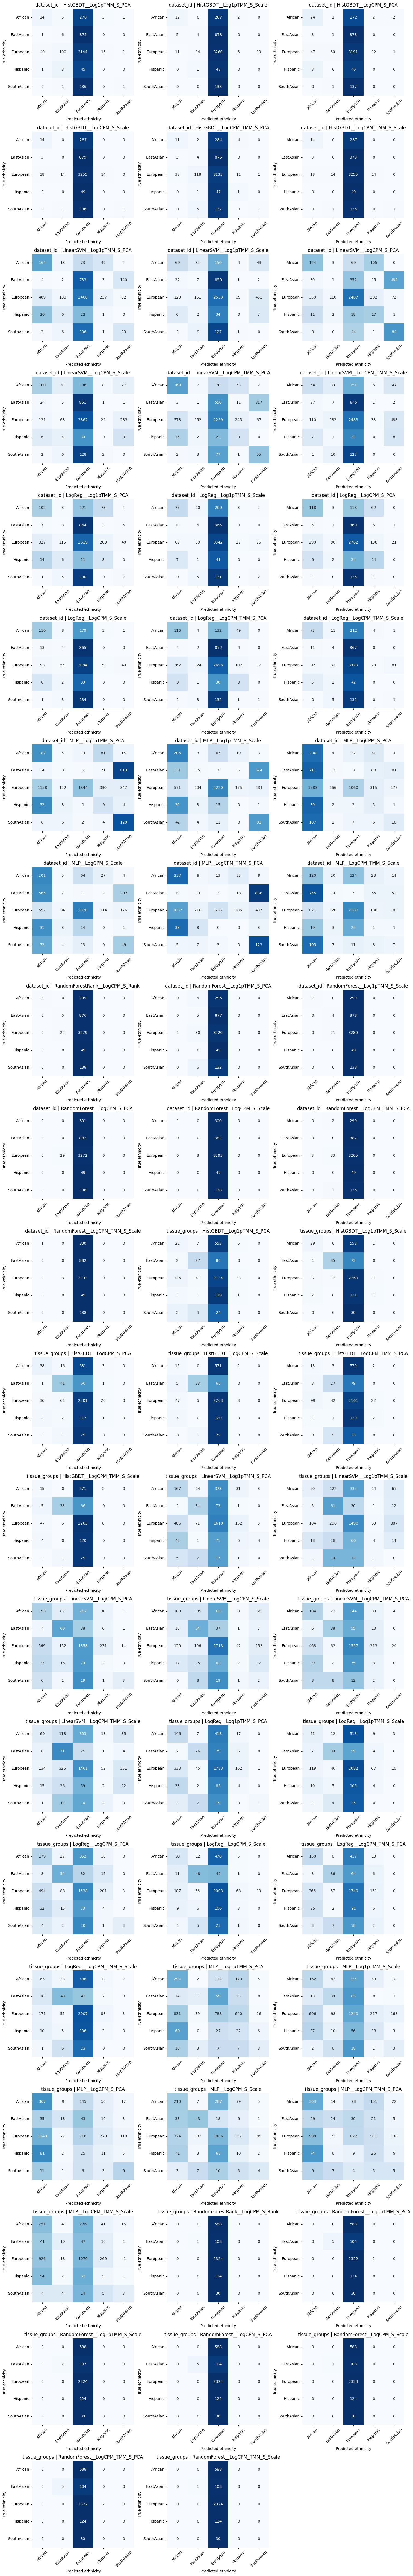

In [30]:
summary_by_family = (
    combined_fold_metrics
    .assign(model_family=lambda df: df["model"].str.split("__").str[0])
    .groupby(["split_scheme", "model_family", "model"])[["acc", "balanced_acc", "macro_f1", "weighted_f1"]]
    .mean()
    .reset_index()
    .sort_values(["split_scheme", "model_family", "model"])
)

display(summary_by_family)

prediction_df = pd.DataFrame(prediction_records)
display(prediction_df.head())

def plot_model_confusion_matrices(prediction_df, class_names, max_cols=3):
    panel_names = sorted(
        prediction_df.assign(panel=prediction_df["split_scheme"] + " | " + prediction_df["model"])["panel"].unique()
    )

    n_cols = min(max_cols, len(panel_names))
    n_rows = int(np.ceil(len(panel_names) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4.5 * n_rows), squeeze=False)

    for ax, panel_name in zip(axes.flatten(), panel_names):
        split_scheme, model_name = panel_name.split(" | ", 1)
        df_model = prediction_df[(prediction_df["split_scheme"] == split_scheme) & (prediction_df["model"] == model_name)]
        cm_counts = confusion_matrix(df_model["truth"], df_model["prediction"], labels=class_names)
        cm_props = confusion_matrix(
            df_model["truth"],
            df_model["prediction"],
            labels=class_names,
            normalize="true",
        )
        sns.heatmap(
            cm_props,
            ax=ax,
            cmap="Blues",
            vmin=0,
            vmax=1,
            annot=cm_counts,
            fmt="d",
            xticklabels=class_names,
            yticklabels=class_names,
            cbar=False,
        )
        ax.set_title(panel_name)
        ax.set_xlabel("Predicted ethnicity")
        ax.set_ylabel("True ethnicity")
        ax.tick_params(axis="x", rotation=45)
        ax.tick_params(axis="y", rotation=0)

    for ax in axes.flatten()[len(panel_names):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plot_model_confusion_matrices(prediction_df, class_names=class_names)


Here, should go to R for comparing all models visualisation, including labelTransfer

# Final predictions with the best model

In [32]:
final_recipe_name = "HistGBDT__Log1pTMM_S_PCA"
query_adata = adata_query[:, adata_ref.var_names].copy()
X_ref_final = feature_matrices[("Log1pTMM", "S")]
X_query_final = extract_layer(query_adata, "logcounts_tmm", marker_mask)

y_ref_final = y
sample_w_final, _ = compute_sample_weights(y_ref_final)

X_ref_final_z, final_transform = fit_scaler_pca(X_ref_final, n_pcs=N_PCS)
X_query_final_z = transform_feature_space(X_query_final, final_transform, feature_mode="pca")

final_model = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.1,
    max_iter=300,
    random_state=14,
)
final_model.fit(X_ref_final_z, y_ref_final, sample_weight=sample_w_final)

final_scores = get_model_scores(final_model, X_query_final_z, class_ids=class_ids)
final_pred_int = final_model.predict(X_query_final_z)
final_pred_label = pd.Series(final_pred_int).map(idx_to_eth).to_numpy()

final_pred_df = pd.DataFrame({
    "cell_id": query_adata.obs_names.astype(str),
    "predicted_ethnicity": final_pred_label,
    "predicted_class_id": final_pred_int,
    "prediction_score_max": final_scores.max(axis=1),
    "final_model": final_recipe_name,
})

query_obs = query_adata.obs.copy()

final_pred_df.insert(1, "sample_id", query_obs["sample_id"].astype(str).to_numpy())

for class_idx, class_name in idx_to_eth.items():
    final_pred_df[f"score_{class_name}"] = final_scores[:, class_idx]

final_query_csv = "histgbdt_Log1pTMM_S_PCA_query_predictions.csv"
final_pred_df.to_csv(final_query_csv, index=False)
print("Wrote:", final_query_csv)
display(final_pred_df.head())



Wrote: histgbdt_Log1pTMM_S_PCA_query_predictions.csv


,cell_id,sample_id,predicted_ethnicity,predicted_class_id,prediction_score_max,final_model,score_African,score_EastAsian,score_European,score_Hispanic,score_SouthAsian
0,0013454cf3bd3caf513407fab32beca1,0013454cf3bd3caf513407fab32beca1,European,2,0.858149,HistGBDT__Log1pTMM_S_PCA,7.417718e-03,0.042269,0.858149,9.212462e-02,3.922069e-05
1,002ee55b6dec45e166be1c940ecbcdcf,002ee55b6dec45e166be1c940ecbcdcf,European,2,0.999989,HistGBDT__Log1pTMM_S_PCA,3.094583e-07,0.000009,0.999989,3.400562e-07,2.153995e-06
2,003d3dab80f1d89fa69829a5bb5bf0b1,003d3dab80f1d89fa69829a5bb5bf0b1,European,2,0.999990,HistGBDT__Log1pTMM_S_PCA,3.404882e-07,0.000009,0.999990,4.674964e-08,2.940378e-07
3,00bb4075752d2b2400de7cbcb177f51f,00bb4075752d2b2400de7cbcb177f51f,European,2,0.998646,HistGBDT__Log1pTMM_S_PCA,1.107654e-04,0.000023,0.998646,3.669608e-04,8.523115e-04
4,00bc47f111e7d930186eaaa40a99a995,00bc47f111e7d930186eaaa40a99a995,European,2,0.997918,HistGBDT__Log1pTMM_S_PCA,6.340858e-04,0.001195,0.997918,1.372464e-04,1.153011e-04
